## Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rcParams
%matplotlib inline
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.model_selection import GridSearchCV

## Plot a confusion Matrix Function

## Read the data 

In [2]:
Data = pd.read_csv(r'D:\AI\ai_deploma_master\ai_deploma_master\files\creditcard.csv')
#https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud

In [3]:
Data.head(5)

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


## Drop the variable we do not need

In [4]:
#Drop Time
dataset = Data.drop(['Time'],axis=1)
#dataset =data

## Plot Correlation chart

## Know the classes or levels of the variable (Transaction)

In [5]:
dataset['Class'].unique()

array([0, 1])

## Get the count of the classes or levels

Text(0.5, 1.0, 'Count of each Target Class')

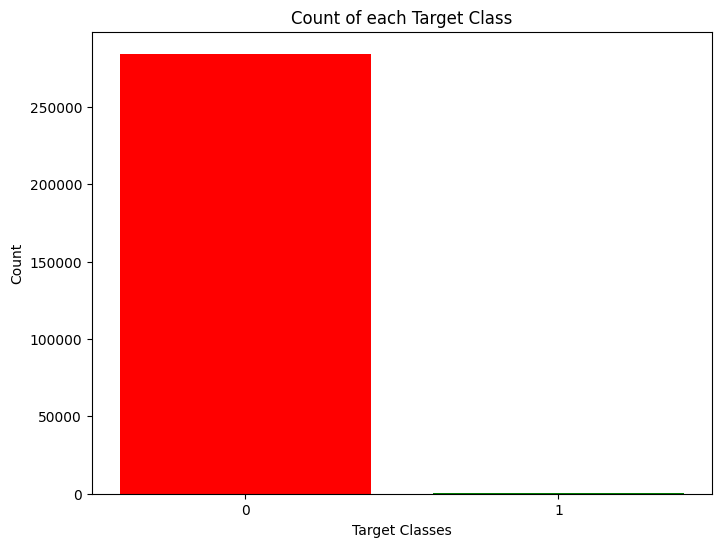

In [6]:
rcParams['figure.figsize'] = 8,6
plt.bar(dataset['Class'].unique(), dataset['Class'].value_counts(), color = ['red', 'green'])
plt.xticks([0, 1])
plt.xlabel('Target Classes')
plt.ylabel('Count')
plt.title('Count of each Target Class')

### Split the Data to X and Y and Train and testing

In [7]:
#Define the data set as X and Y
y = dataset['Class']
X = dataset.drop(['Class'], axis = 1)

#Split the dataset in training and testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.20, random_state = 0)

## Train One tree

In [8]:
#Define the Grid search parameters
Hyper_paramters={'criterion':['entropy'],'max_depth':[4]}

#Define the five fold Cross Validation
Tree_Gridsearch_paramters=GridSearchCV(DecisionTreeClassifier(),Hyper_paramters,scoring='roc_auc',n_jobs=-1,cv=5,verbose=2)
Tree_crossvalidation=Tree_Gridsearch_paramters.fit(X_train,y_train)


#Print the best hyper paramters combination for the best model
print ("The best paramter combination is ")
print(Tree_crossvalidation.best_params_)  #gets best estimator
Final_Model=Tree_crossvalidation.best_estimator_ #gets best estimator
print("The best AUC score was ")
print(Tree_crossvalidation.best_score_)  #gets best score for best estimator # -0.83828599184062269
importances=Tree_crossvalidation.best_estimator_.feature_importances_
importances
#Tree_crossvalidation.cv_results_  #gets summary of results
#Print all importance
Names=list(X_train.columns.values)
for f in range(X_train.shape[1]):
    print((Names[f],  importances[[f]]))
    

Fitting 5 folds for each of 1 candidates, totalling 5 fits
The best paramter combination is 
{'criterion': 'entropy', 'max_depth': 4}
The best AUC score was 
0.9415890197291981
('V1', array([0.]))
('V2', array([0.]))
('V3', array([0.]))
('V4', array([0.02073626]))
('V5', array([0.]))
('V6', array([0.]))
('V7', array([0.]))
('V8', array([0.]))
('V9', array([0.]))
('V10', array([0.05680758]))
('V11', array([0.]))
('V12', array([0.]))
('V13', array([0.]))
('V14', array([0.14411129]))
('V15', array([0.]))
('V16', array([0.00747344]))
('V17', array([0.75232589]))
('V18', array([0.]))
('V19', array([0.]))
('V20', array([0.01072125]))
('V21', array([0.00364485]))
('V22', array([0.]))
('V23', array([0.00417945]))
('V24', array([0.]))
('V25', array([0.]))
('V26', array([0.]))
('V27', array([0.]))
('V28', array([0.]))
('Amount', array([0.]))


## Train the Bagging Model

In [9]:
#Define the Grid search parameters
Hyper_paramters={'n_estimators':[3,4,5,6] }

#Define the five fold Cross Validation
Tree_Gridsearch_paramters=GridSearchCV(BaggingClassifier(),Hyper_paramters,scoring='roc_auc',n_jobs=-1,cv=5,verbose=2)
Tree_crossvalidation=Tree_Gridsearch_paramters.fit(X_train,y_train)


#Print the best hyper paramters combination for the best model
print ("The best paramter combination is ")
print(Tree_crossvalidation.best_params_)  #gets best estimator
Final_Model=Tree_crossvalidation.best_estimator_ #gets best estimator
print("The best AUC score was ")
print(Tree_crossvalidation.best_score_)  #gets best score for best estimator # -0.83828599184062269

#Predict using the model and report resulls
#Prediction Using the Model
y_pred = Final_Model.predict(X_test)
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
cm1 = confusion_matrix(y_test, y_pred)
print(cm1)
print(classification_report(y_test, y_pred, target_names=["Safe", "Fraud"]))

#Calculate sensitivity and specificity

total1=sum(sum(cm1))
accuracy1=(cm1[0,0]+cm1[1,1])/total1
print ('Accuracy : ', accuracy1)

sensitivity1 = cm1[0,0]/(cm1[0,0]+cm1[0,1])
print('Sensitivity : ', sensitivity1 )

specificity1 = cm1[1,1]/(cm1[1,0]+cm1[1,1])
print('Specificity : ', specificity1)
    

Fitting 5 folds for each of 4 candidates, totalling 20 fits
The best paramter combination is 
{'n_estimators': 5}
The best AUC score was 
0.9166435380867719
[[56852     9]
 [   23    78]]
              precision    recall  f1-score   support

        Safe       1.00      1.00      1.00     56861
       Fraud       0.90      0.77      0.83       101

    accuracy                           1.00     56962
   macro avg       0.95      0.89      0.91     56962
weighted avg       1.00      1.00      1.00     56962

Accuracy :  0.9994382219725431
Sensitivity :  0.9998417192803504
Specificity :  0.7722772277227723


### Train the Random Forst Model

In [10]:
from sklearn.ensemble import RandomForestClassifier

#Define the Grid search parameters
Hyper_paramters={'criterion':['entropy'],'max_depth':[4,10],'n_estimators':[50, 100], 'max_features':['sqrt'] }

#Define the five fold Cross Validation max_features
Tree_Gridsearch_paramters=GridSearchCV(RandomForestClassifier(),Hyper_paramters,scoring='roc_auc',n_jobs=-1,cv=5,verbose=2)
Tree_crossvalidation=Tree_Gridsearch_paramters.fit(X_train,y_train)


#Print the best hyper paramters combination for the best model
print ("The best paramter combination is ")
print(Tree_crossvalidation.best_params_)  #gets best estimator
Final_Model=Tree_crossvalidation.best_estimator_ #gets best estimator
print("The best AUC score was ")
print(Tree_crossvalidation.best_score_)  #gets best score for best estimator # -0.83828599184062269
importances=Tree_crossvalidation.best_estimator_.feature_importances_
importances
#Tree_crossvalidation.cv_results_  #gets summary of results
#Print all importance
Names=list(X_train.columns.values)
for f in range(X_train.shape[1]):
    print((Names[f],  importances[[f]]))
    

Fitting 5 folds for each of 4 candidates, totalling 20 fits
The best paramter combination is 
{'criterion': 'entropy', 'max_depth': 10, 'max_features': 'sqrt', 'n_estimators': 100}
The best AUC score was 
0.9772517792184807
('V1', array([0.00790828]))
('V2', array([0.01078174]))
('V3', array([0.02777528]))
('V4', array([0.04029303]))
('V5', array([0.00862662]))
('V6', array([0.01365061]))
('V7', array([0.03366144]))
('V8', array([0.00961284]))
('V9', array([0.02570382]))
('V10', array([0.11908595]))
('V11', array([0.06990033]))
('V12', array([0.13142957]))
('V13', array([0.00575484]))
('V14', array([0.16822431]))
('V15', array([0.00546343]))
('V16', array([0.05011606]))
('V17', array([0.15647348]))
('V18', array([0.02613945]))
('V19', array([0.0106085]))
('V20', array([0.00985532]))
('V21', array([0.01557047]))
('V22', array([0.006175]))
('V23', array([0.00473956]))
('V24', array([0.00418404]))
('V25', array([0.00468164]))
('V26', array([0.01035389]))
('V27', array([0.00726171]))
('V28

# Predict using the best model (The last model trained)

In [11]:
#Prediction Using the Model
y_pred = Final_Model.predict(X_test)
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
cm1 = confusion_matrix(y_test, y_pred)
print(cm1)
print(classification_report(y_test, y_pred, target_names=["Safe", "Fraud"]))

#Calculate sensitivity and specificity

total1=sum(sum(cm1))
accuracy1=(cm1[0,0]+cm1[1,1])/total1
print ('Accuracy : ', accuracy1)

sensitivity1 = cm1[0,0]/(cm1[0,0]+cm1[0,1])
print('Sensitivity : ', sensitivity1 )

specificity1 = cm1[1,1]/(cm1[1,0]+cm1[1,1])
print('Specificity : ', specificity1)

# Accuracy :  0.9993504441557529
# Sensitivity :  0.9998241325337226
# Specificity :  0.7326732673267327
#https://towardsdatascience.com/accuracy-recall-precision-f-score-specificity-which-to-optimize-on-867d3f11124

[[56854     7]
 [   22    79]]
              precision    recall  f1-score   support

        Safe       1.00      1.00      1.00     56861
       Fraud       0.92      0.78      0.84       101

    accuracy                           1.00     56962
   macro avg       0.96      0.89      0.92     56962
weighted avg       1.00      1.00      1.00     56962

Accuracy :  0.9994908886626171
Sensitivity :  0.9998768927736058
Specificity :  0.7821782178217822


# Plot ROC Curve

C:\Users\DELL\AppData\Local\Temp\ipykernel_20920\2723315730.py:5: FutureWarning: Series.ravel is deprecated. The underlying array is already 1D, so ravel is not necessary.  Use `to_numpy()` for conversion to a numpy array instead.
  fpr, tpr, thresholds = roc_curve(y_test.ravel(),y_pred)


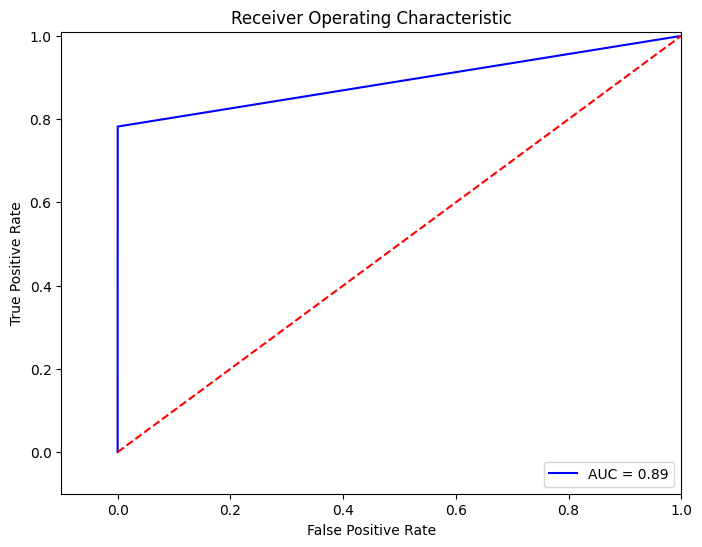

In [12]:
from sklearn.metrics import confusion_matrix,precision_recall_curve,auc,roc_auc_score,roc_curve,recall_score,classification_report 

plt.rcParams.update({'font.size': 10})

fpr, tpr, thresholds = roc_curve(y_test.ravel(),y_pred)
roc_auc = auc(fpr,tpr)

# Plot ROC
plt.title('Receiver Operating Characteristic')
plt.plot(fpr, tpr, 'b',label='AUC = %0.2f'% roc_auc)
plt.legend(loc='lower right')
plt.plot([0,1],[0,1],'r--')
plt.xlim([-0.1,1.0])
plt.ylim([-0.1,1.01])
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')

plt.show()


# Gradient Boosting

In [13]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import confusion_matrix, classification_report

# Define the Grid search parameters for Gradient Boosting
gbm_params = {
    'n_estimators': [50, 100],
    'learning_rate': [0.01, 0.1],
    'max_depth': [3, 5, 7],
    'subsample': [0.8, 1.0],
    'min_samples_split': [10]
}

# Gradient Boosting Grid Search
gbm_grid_search = GridSearchCV(GradientBoostingClassifier(), gbm_params, scoring='roc_auc', n_jobs=-1, cv=3, verbose=2)
gbm_cv = gbm_grid_search.fit(X_train, y_train)



Fitting 3 folds for each of 24 candidates, totalling 72 fits


KeyboardInterrupt: 

In [ ]:
print ("The best paramter combination is ")
print(gbm_cv.best_params_)  #gets best estimator

# Prediction Using the Model
y_pred_gbm = gbm_cv.best_estimator_.predict(X_test)
cm_gbm = confusion_matrix(y_test, y_pred_gbm)
print(cm_gbm)
print(classification_report(y_test, y_pred_gbm, target_names=["Safe", "Fraud"]))

# Calculate sensitivity, specificity, and accuracy
total_gbm = sum(sum(cm_gbm))
accuracy_gbm = (cm_gbm[0,0] + cm_gbm[1,1]) / total_gbm
print('Accuracy (GBM): ', accuracy_gbm)

sensitivity_gbm = cm_gbm[0,0] / (cm_gbm[0,0] + cm_gbm[0,1])
print('Sensitivity (GBM): ', sensitivity_gbm)

specificity_gbm = cm_gbm[1,1] / (cm_gbm[1,0] + cm_gbm[1,1])
print('Specificity (GBM): ', specificity_gbm)

# XGB

In [14]:
%pip install xgboost

   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.3/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.3/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.3/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.3/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.3/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.5/101.7 MB 216.0 kB/s eta 0:07:


[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [15]:
#%pip install xgboost
from xgboost import XGBClassifier
from sklearn.metrics import confusion_matrix, classification_report

# Define the Grid search parameters for XGBoost
xgb_params = {
    'n_estimators': [50,60,70,80,90, 100],
    'learning_rate': [0.01,0.02,0.05],
    'max_depth': [3, 5, 7],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

# XGBoost Grid Search
xgb_grid_search = GridSearchCV(XGBClassifier(), xgb_params, scoring='roc_auc', n_jobs=-1, cv=2, verbose=2)
xgb_cv = xgb_grid_search.fit(X_train, y_train)


Fitting 2 folds for each of 216 candidates, totalling 432 fits


KeyboardInterrupt: 

In [ ]:
print ("The best paramter combination is ")
print(xgb_cv.best_params_)  #gets best estimator

# Prediction Using the Model
y_pred_xgb = xgb_cv.best_estimator_.predict(X_test)
cm_xgb = confusion_matrix(y_test, y_pred_xgb)
print(cm_xgb)
print(classification_report(y_test, y_pred_xgb, target_names=["Safe", "Fraud"]))

# Calculate sensitivity, specificity, and accuracy
total_xgb = sum(sum(cm_xgb))
accuracy_xgb = (cm_xgb[0,0] + cm_xgb[1,1]) / total_xgb
print('Accuracy (XGBoost): ', accuracy_xgb)

sensitivity_xgb = cm_xgb[0,0] / (cm_xgb[0,0] + cm_xgb[0,1])
print('Sensitivity (XGBoost): ', sensitivity_xgb)

specificity_xgb = cm_xgb[1,1] / (cm_xgb[1,0] + cm_xgb[1,1])
print('Specificity (XGBoost): ', specificity_xgb)

# LightGBM

In [ ]:
#%pip install lightgbm

In [ ]:
from lightgbm import LGBMClassifier
from sklearn.metrics import confusion_matrix, classification_report

# Define the Grid search parameters for LightGBM
lgbm_params = {
    'n_estimators': [50, 100],
    'learning_rate': [0.01, 0.1],
    'max_depth': [5,6, 7,8],
    'subsample': [1.0]
}

# LightGBM Grid Search
lgbm_grid_search = GridSearchCV(LGBMClassifier(), lgbm_params, scoring='roc_auc', n_jobs=-1, cv=2, verbose=2)
lgbm_cv = lgbm_grid_search.fit(X_train, y_train)

In [ ]:
print ("The best paramter combination is ")
print(gbm_cv.best_params_)  #gets best estimator

# Prediction Using the Model
y_pred_lgbm = lgbm_cv.best_estimator_.predict(X_test)
cm_lgbm = confusion_matrix(y_test, y_pred_lgbm)
print(cm_lgbm)
print(classification_report(y_test, y_pred_lgbm, target_names=["Safe", "Fraud"]))

# Calculate sensitivity, specificity, and accuracy
total_lgbm = sum(sum(cm_lgbm))
accuracy_lgbm = (cm_lgbm[0,0] + cm_lgbm[1,1]) / total_lgbm
print('Accuracy (LightGBM): ', accuracy_lgbm)

sensitivity_lgbm = cm_lgbm[0,0] / (cm_lgbm[0,0] + cm_lgbm[0,1])
print('Sensitivity (LightGBM): ', sensitivity_lgbm)

specificity_lgbm = cm_lgbm[1,1] / (cm_lgbm[1,0] + cm_lgbm[1,1])
print('Specificity (LightGBM): ', specificity_lgbm)

# CatBoost

In [ ]:
from catboost import CatBoostClassifier
from sklearn.metrics import confusion_matrix, classification_report

# Define the Grid search parameters for CatBoost
catboost_params = {
    'iterations': [100, 200],
    'learning_rate': [0.01, 0.1],
    'depth': [3, 5, 7]
}

# CatBoost Grid Search
catboost_grid_search = GridSearchCV(CatBoostClassifier(verbose=0), catboost_params, scoring='roc_auc', n_jobs=-1, cv=5, verbose=2)
catboost_cv = catboost_grid_search.fit(X_train, y_train)

In [ ]:
# Prediction Using the Model
y_pred_catboost = catboost_cv.best_estimator_.predict(X_test)
cm_catboost = confusion_matrix(y_test, y_pred_catboost)
print(cm_catboost)
print(classification_report(y_test, y_pred_catboost, target_names=["Safe", "Fraud"]))

# Calculate sensitivity, specificity, and accuracy
total_catboost = sum(sum(cm_catboost))
accuracy_catboost = (cm_catboost[0,0] + cm_catboost[1,1]) / total_catboost
print('Accuracy (CatBoost): ', accuracy_catboost)

sensitivity_catboost = cm_catboost[0,0] / (cm_catboost[0,0] + cm_catboost[0,1])
print('Sensitivity (CatBoost): ', sensitivity_catboost)

specificity_catboost = cm_catboost[1,1] / (cm_catboost[1,0] + cm_catboost[1,1])
print('Specificity (CatBoost): ', specificity_catboost)

# AdaBoost

In [ ]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import confusion_matrix, classification_report

# Define the Grid search parameters for AdaBoost
adaboost_params = {
    'n_estimators': [50,70, 100, 150, 200],
    'learning_rate': [0.01, 0.1, 1.0]
}

# AdaBoost Grid Search
adaboost_grid_search = GridSearchCV(AdaBoostClassifier(), adaboost_params, scoring='roc_auc', n_jobs=-1, cv=5, verbose=2)
adaboost_cv = adaboost_grid_search.fit(X_train, y_train)

In [ ]:
# Prediction Using the Model
y_pred_adaboost = adaboost_cv.best_estimator_.predict(X_test)
cm_adaboost = confusion_matrix(y_test, y_pred_adaboost)
print(cm_adaboost)
print(classification_report(y_test, y_pred_adaboost, target_names=["Safe", "Fraud"]))

# Calculate sensitivity, specificity, and accuracy
total_adaboost = sum(sum(cm_adaboost))
accuracy_adaboost = (cm_adaboost[0,0] + cm_adaboost[1,1]) / total_adaboost
print('Accuracy (AdaBoost): ', accuracy_adaboost)

sensitivity_adaboost = cm_adaboost[0,0] / (cm_adaboost[0,0] + cm_adaboost[0,1])
print('Sensitivity (AdaBoost): ', sensitivity_adaboost)

specificity_adaboost = cm_adaboost[1,1] / (cm_adaboost[1,0] + cm_adaboost[1,1])
print('Specificity (AdaBoost): ', specificity_adaboost)